# Correlations in data

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
all_data = pd.read_csv("../data/sam3/cleaned_data.csv", low_memory=False)

# Drop stroke team column
data = all_data.drop(columns=['stroke_team'])

In [3]:
# Assumes `data` is your existing pandas DataFrame
numeric_data = data.select_dtypes(include=[np.number])

cov_matrix = numeric_data.cov()
corr_matrix = numeric_data.corr()  # Pearson by default

# Convert to pandas DataFrame for easier handling and saving
cov_df = pd.DataFrame(cov_matrix)
corr_df = pd.DataFrame(corr_matrix)

# Save to output folder
cov_df.to_csv('./output/covariance_matrix.csv', index=True)
corr_df.to_csv('./output/correlation_matrix.csv', index=True)

In [4]:

def plot_matrix(matrix, title, cmap='coolwarm', add_values=False, use_log_scale=False):
    fig, ax = plt.subplots(figsize=(16, 12))
    if use_log_scale:
        positive = matrix.to_numpy()[matrix.to_numpy() > 0]
        norm = plt.matplotlib.colors.LogNorm(vmin=positive.min(), vmax=positive.max()) if positive.size else None
        im = ax.imshow(matrix, cmap=cmap, norm=norm)
    else:
        im = ax.imshow(matrix, cmap=cmap,
                       vmin=-1 if 'Correlation' in title else None,
                       vmax=1 if 'Correlation' in title else None)

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(matrix.columns)

    if add_values:
        for i in range(len(matrix.columns)):
            for j in range(len(matrix.columns)):
                ax.text(j, i, f"{matrix.iloc[i, j]:.2f}",
                        ha='center', va='center',
                        color='black', fontsize=8)

    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

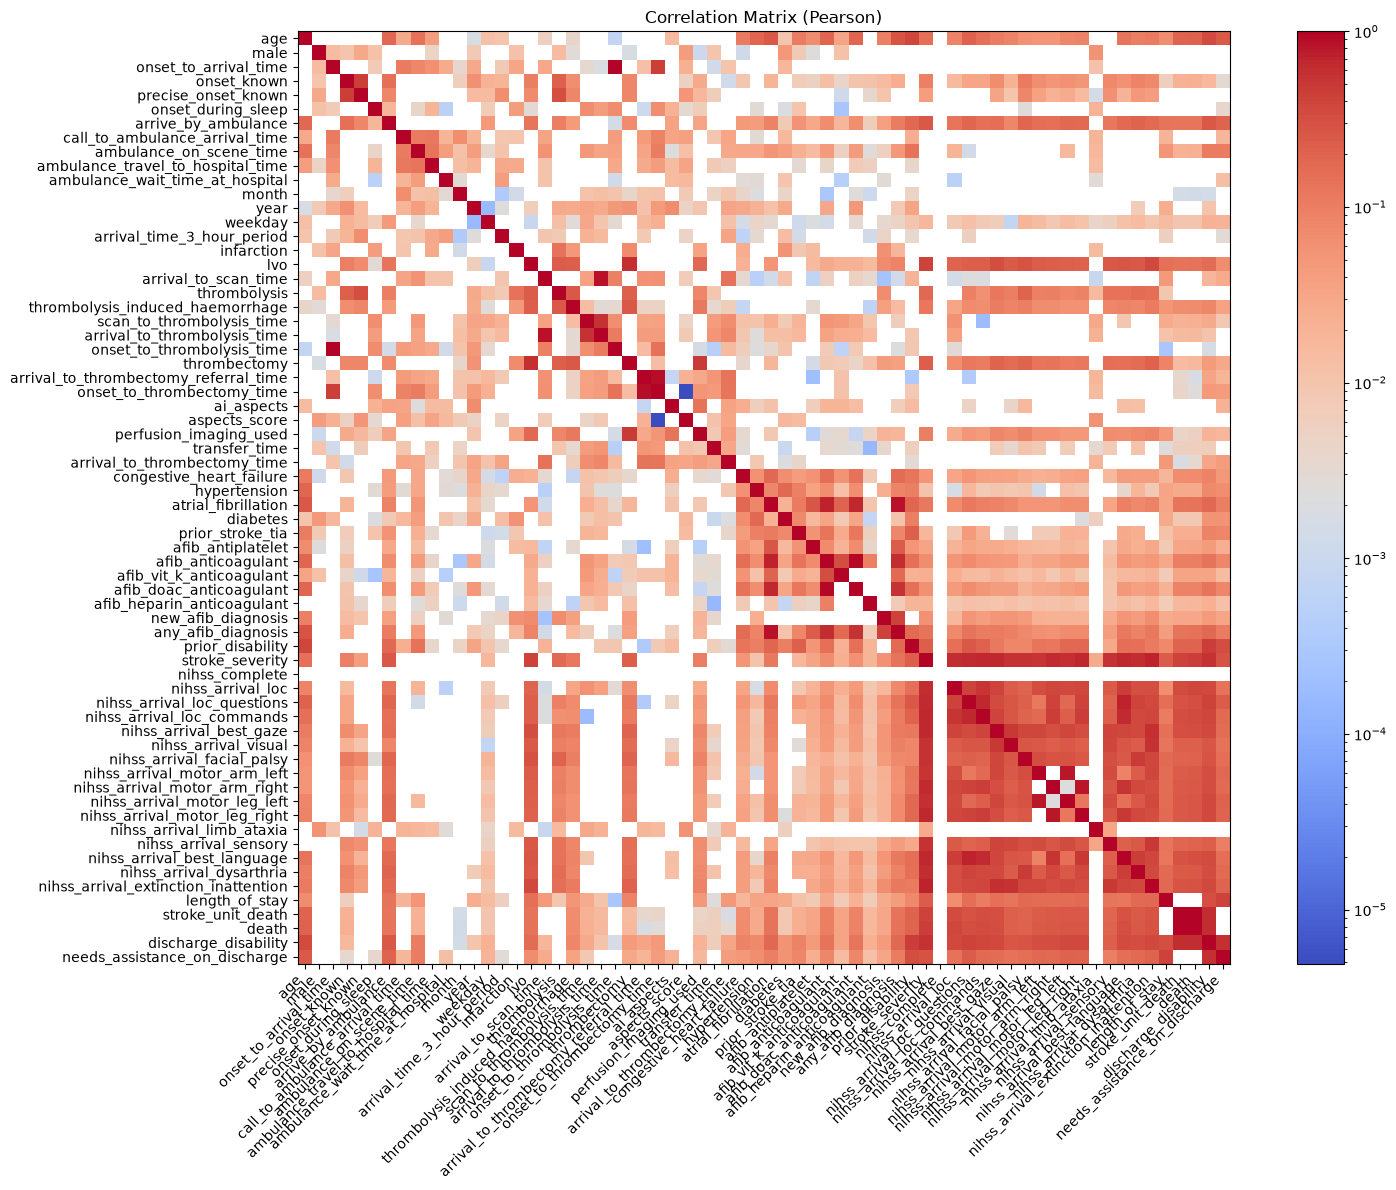

In [5]:
plot_matrix(corr_matrix, "Correlation Matrix (Pearson)", cmap='coolwarm', use_log_scale=True)

In [ ]:
# Identify all correlations above a certain threshold (e.g., 0.8)
threshold = 0.05
high_corr = np.where(corr_matrix > threshold)
high_corr_pairs = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y]) for x, y in zip(*high_corr) if x < y]
# Convert to DataFrame for easier viewing and saving
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
# Sort by absolute correlation value
high_corr_df = high_corr_df.reindex(high_corr_df['Correlation'].abs().sort_values(ascending=False).index)
# Save
high_corr_df.to_csv('./output/high_correlations.csv', index=False)
# Show
high_corr_df

,Feature 1,Feature 2,Correlation
535,stroke_unit_death,death,1.000000
35,onset_to_arrival_time,onset_to_thrombolysis_time,0.994033
289,afib_anticoagulant,afib_doac_anticoagulant,0.909337
208,arrival_to_thrombectomy_referral_time,onset_to_thrombectomy_time,0.904249
253,atrial_fibrillation,any_afib_diagnosis,0.854609
...,...,...,...
263,atrial_fibrillation,nihss_arrival_motor_arm_right,0.051157
50,onset_known,nihss_arrival_motor_leg_right,0.051033
307,afib_doac_anticoagulant,nihss_arrival_loc_commands,0.050712
294,afib_anticoagulant,nihss_arrival_loc,0.050623
